<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">
<h1 style="margin: 0; color: #2c5f2d;">Decision tree to predict the Diabetes</h1>
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Description of the problem
This dataset originally comes from the National Institute of Diabetes and Digestive and Kidney Diseases. The goal is to predict, based on diagnostic measures, whether or not a patient has diabetes.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Import libraries and load datasets
</div>



In [19]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import normaltest, shapiro, skew, kurtosis

# Libraries for preprocessing and Machine Learning 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_validate
from sklearn.metrics import precision_recall_curve, average_precision_score

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [20]:
# Load preprocessed data
BASE_PATH = "../data/processed/04-diabetes/"

X_train = pd.read_csv(f"{BASE_PATH}X_train.csv")
X_test = pd.read_csv(f"{BASE_PATH}X_test.csv")
y_train = pd.read_csv(f"{BASE_PATH}y_train.csv").squeeze("columns")
y_test = pd.read_csv(f"{BASE_PATH}y_test.csv").squeeze("columns")

print("✓ Data loaded successfully!")
print(f"\nDataset Shape:")
print(f"   Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"   Test set:     {X_test.shape[0]} samples, {X_test.shape[1]} features")

print("\nClass Distribution:")
print(f"   Training: {dict(y_train.value_counts().sort_index())}")
print(f"   Test:     {dict(y_test.value_counts().sort_index())}")


✓ Data loaded successfully!

Dataset Shape:
   Training set: 614 samples, 8 features
   Test set:     154 samples, 8 features

Class Distribution:
   Training: {0: np.int64(400), 1: np.int64(214)}
   Test:     {0: np.int64(100), 1: np.int64(54)}


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Data Requirements for Decision Trees

**Decision Trees do NOT require:**
- Normality tests (Shapiro-Wilk, Q-Q plots)
- Scaling/Standardization
- Log/Square transformations
- Outlier removal
- Multicollinearity checks
- Linearity assumptions

**Decision Trees DO require:**
- Missing value handling
- Duplicate row removal
- Target variable analysis (class imbalance detection)
- Feature data type analysis (categorical encoding if needed)
- Feature cardinality check (high cardinality can cause overfitting)
- Appropriate metric selection (use F1-Score/Precision/Recall for imbalanced data)

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 1. Baseline Decision Tree Model

Train an initial Decision Tree with default parameters to establish baseline performance.

</div>

In [21]:
# Create and train baseline Decision Tree
print("="*70)
print("BASELINE DECISION TREE MODEL")
print("="*70)

# Initialize model
dt_baseline = DecisionTreeClassifier(random_state=42)

# Train model
print("\nTraining baseline model...")
dt_baseline.fit(X_train, y_train)
print("✓ Training complete!")

# Display model parameters
print(f"\nModel Parameters:")
print("-"*70)
print(f"   Criterion: {dt_baseline.criterion}")
print(f"   Splitter: {dt_baseline.splitter}")
print(f"   Max Depth: {dt_baseline.max_depth if dt_baseline.max_depth else 'Unlimited'}")
print(f"   Min Samples Split: {dt_baseline.min_samples_split}")
print(f"   Min Samples Leaf: {dt_baseline.min_samples_leaf}")

# Tree complexity
print(f"\nTree Complexity:")
print("-"*70)
print(f"   Tree Depth: {dt_baseline.get_depth()}")
print(f"   Number of Leaves: {dt_baseline.get_n_leaves()}")
print(f"   Total Nodes: {dt_baseline.tree_.node_count}")

BASELINE DECISION TREE MODEL

Training baseline model...
✓ Training complete!

Model Parameters:
----------------------------------------------------------------------
   Criterion: gini
   Splitter: best
   Max Depth: Unlimited
   Min Samples Split: 2
   Min Samples Leaf: 1

Tree Complexity:
----------------------------------------------------------------------
   Tree Depth: 14
   Number of Leaves: 111
   Total Nodes: 221


In [22]:
# Make predictions
y_train_pred = dt_baseline.predict(X_train)
y_test_pred = dt_baseline.predict(X_test)

# Get probability predictions for ROC curve
y_train_pred_proba = dt_baseline.predict_proba(X_train)[:, 1]
y_test_pred_proba = dt_baseline.predict_proba(X_test)[:, 1]

print("✓ Predictions generated successfully!")

✓ Predictions generated successfully!


In [23]:
# Evaluate model performance
print("="*70)
print("BASELINE MODEL EVALUATION")
print("="*70)

# Training set performance
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

print("\nTraining Set Performance:")
print("-"*70)
print(f"   Accuracy:  {train_accuracy:.4f}")
print(f"   Precision: {train_precision:.4f}")
print(f"   Recall:    {train_recall:.4f}")
print(f"   F1-Score:  {train_f1:.4f}")

# Testing set performance
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("\nTesting Set Performance:")
print("-"*70)
print(f"   Accuracy:  {test_accuracy:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")

# Check for overfitting
print("\nOverfitting Analysis:")
print("-"*70)
accuracy_diff = train_accuracy - test_accuracy
print(f"   Training Accuracy: {train_accuracy:.4f}")
print(f"   Testing Accuracy:  {test_accuracy:.4f}")
print(f"   Difference:        {accuracy_diff:.4f}")

if accuracy_diff > 0.1:
    print("Warning: Potential overfitting detected!")
    print("Consider pruning the tree or using cross-validation")
elif accuracy_diff > 0.05:
    print("Moderate overfitting detected")
    print("Model performs better on training data")
else:
    print("Good generalization - no significant overfitting!")

# Classification Report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("="*70)
print("\n", classification_report(y_test, y_test_pred, 
                                   target_names=['No Diabetes', 'Has Diabetes']))

BASELINE MODEL EVALUATION

Training Set Performance:
----------------------------------------------------------------------
   Accuracy:  1.0000
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000

Testing Set Performance:
----------------------------------------------------------------------
   Accuracy:  0.6818
   Precision: 0.5532
   Recall:    0.4815
   F1-Score:  0.5149

Overfitting Analysis:
----------------------------------------------------------------------
   Training Accuracy: 1.0000
   Testing Accuracy:  0.6818
   Difference:        0.3182
Consider pruning the tree or using cross-validation

DETAILED CLASSIFICATION REPORT (Test Set)

               precision    recall  f1-score   support

 No Diabetes       0.74      0.79      0.76       100
Has Diabetes       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### 1.1 Max Depth Analysis — Finding the Optimal Tree Depth

Since overfitting was detected (unlimited depth → 14 levels, 221 nodes), we sweep `max_depth` from 1 to 20
to find the "sweet spot" where **test performance peaks** before it starts diverging from training performance.

**What to look for:**
- **Train curve** rises monotonically (more depth = better fit to training data).
- **Test curve** rises, peaks, then flattens or drops (overfitting region).
- The **optimal depth** is where the test F1-Score is highest.
- The **overfitting gap** (train − test) widens after that point.

</div>


MAX DEPTH ANALYSIS — BASELINE DATASET (original X_train / X_test)

  Depth |  Train Acc |  Test Acc |  Train F1 |  Test F1 | Overfit Gap | Leaves
---------------------------------------------------------------------------
      1 |     0.7606 |    0.6948 |    0.5304 |   0.3896 |      0.0658 |      2
      2 |     0.7638 |    0.6883 |    0.5338 |   0.3684 |      0.0755 |      4
      3 |     0.7687 |    0.6883 |    0.5419 |   0.3684 |      0.0804 |      7
      4 |     0.7948 |    0.7857 |    0.7123 |   0.6916 |      0.0091 |     11 ◄ BEST F1
      5 |     0.8143 |    0.7597 |    0.7635 |   0.6783 |      0.0546 |     19
      6 |     0.8502 |    0.7468 |    0.7540 |   0.5618 |      0.1034 |     32
      7 |     0.8795 |    0.7532 |    0.8213 |   0.6042 |      0.1262 |     45
      8 |     0.9153 |    0.7143 |    0.8750 |   0.5319 |      0.2010 |     60
      9 |     0.9397 |    0.7208 |    0.9117 |   0.5169 |      0.2190 |     73
     10 |     0.9625 |    0.6753 |    0.9451 |   0.4898 |

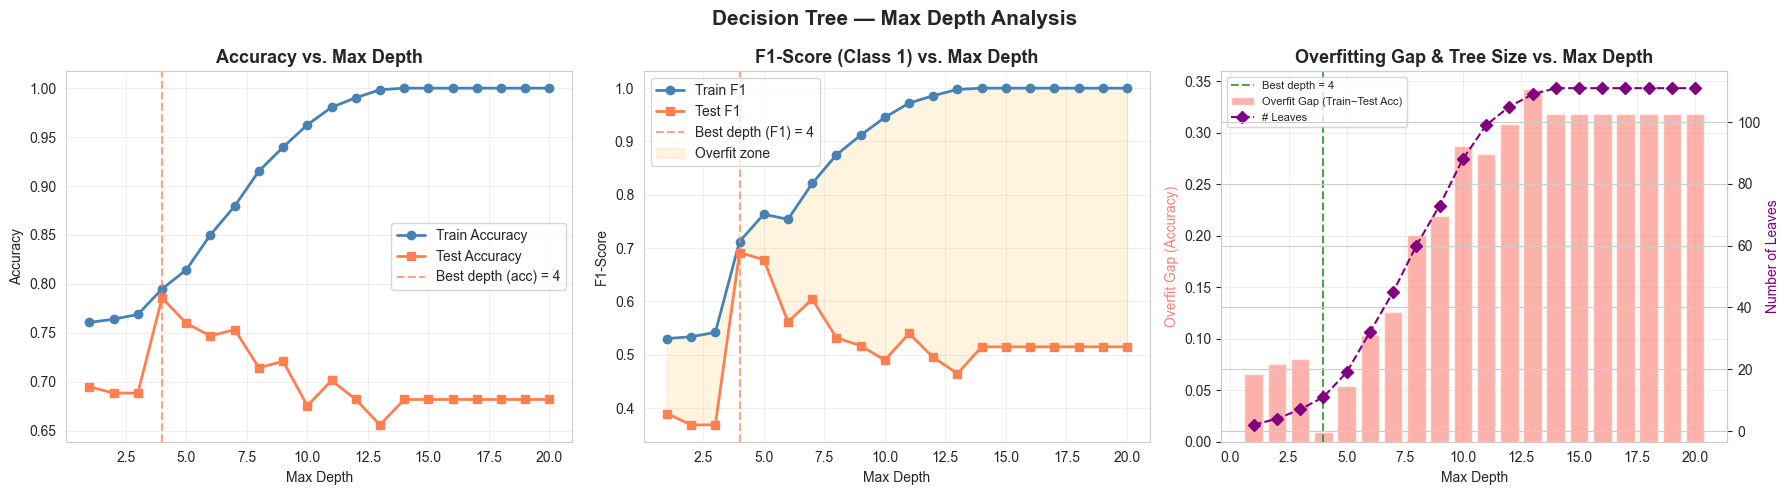


CONCLUSION
  Best max_depth for Test F1-Score  → 4
  Best max_depth for Test Accuracy  → 4
  At depth 4: Test F1 = 0.6916, Overfit Gap = 0.0091

  Recommendation: use max_depth=4 as the starting point
  for pruning — it maximises recall/F1 before overfitting takes hold.


In [24]:
print("="*70)
print("MAX DEPTH ANALYSIS — BASELINE DATASET (original X_train / X_test)")
print("="*70)

depths = range(1, 21)
depth_results = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    y_tr_pred = clf.predict(X_train)
    y_te_pred = clf.predict(X_test)

    depth_results.append({
        "Max Depth":         d,
        "Train Accuracy":    accuracy_score(y_train, y_tr_pred),
        "Test Accuracy":     accuracy_score(y_test,  y_te_pred),
        "Train F1":          f1_score(y_train, y_tr_pred),
        "Test F1":           f1_score(y_test,  y_te_pred),
        "Train Recall":      recall_score(y_train, y_tr_pred),
        "Test Recall":       recall_score(y_test,  y_te_pred),
        "Overfit Gap (Acc)": accuracy_score(y_train, y_tr_pred) - accuracy_score(y_test, y_te_pred),
        "N Leaves":          clf.get_n_leaves(),
        "N Nodes":           clf.tree_.node_count,
    })

depth_df = pd.DataFrame(depth_results).set_index("Max Depth")

# ── locate optimal depth ──────────────────────────────────────────────
best_depth_f1  = depth_df["Test F1"].idxmax()
best_depth_acc = depth_df["Test Accuracy"].idxmax()

print(f"\n{'Depth':>7} | {'Train Acc':>10} | {'Test Acc':>9} | {'Train F1':>9} | {'Test F1':>8} | {'Overfit Gap':>11} | {'Leaves':>6}")
print("-"*75)
for d, row in depth_df.iterrows():
    marker = " ◄ BEST F1" if d == best_depth_f1 else ""
    print(f"{d:>7} | {row['Train Accuracy']:>10.4f} | {row['Test Accuracy']:>9.4f} | "
          f"{row['Train F1']:>9.4f} | {row['Test F1']:>8.4f} | "
          f"{row['Overfit Gap (Acc)']:>11.4f} | {int(row['N Leaves']):>6}{marker}")

print(f"\nOptimal depth by Test F1-Score:   {best_depth_f1}")
print(f"  Optimal depth by Test Accuracy:   {best_depth_acc}")

# ── Visualisation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 – Accuracy
ax1 = axes[0]
ax1.plot(depth_df.index, depth_df["Train Accuracy"], "o-", color="steelblue",  label="Train Accuracy", linewidth=2)
ax1.plot(depth_df.index, depth_df["Test Accuracy"],  "s-", color="coral",      label="Test Accuracy",  linewidth=2)
ax1.axvline(best_depth_acc, color="coral", linestyle="--", alpha=0.7, label=f"Best depth (acc) = {best_depth_acc}")
ax1.set_title("Accuracy vs. Max Depth",  fontsize=13, fontweight="bold")
ax1.set_xlabel("Max Depth"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(alpha=0.3)

# Plot 2 – F1-Score (Class 1 – Diabetes)
ax2 = axes[1]
ax2.plot(depth_df.index, depth_df["Train F1"], "o-", color="steelblue", label="Train F1",  linewidth=2)
ax2.plot(depth_df.index, depth_df["Test F1"],  "s-", color="coral",     label="Test F1",   linewidth=2)
ax2.axvline(best_depth_f1, color="coral", linestyle="--", alpha=0.7, label=f"Best depth (F1) = {best_depth_f1}")
ax2.fill_between(depth_df.index, depth_df["Train F1"], depth_df["Test F1"],
                 alpha=0.12, color="orange", label="Overfit zone")
ax2.set_title("F1-Score (Class 1) vs. Max Depth", fontsize=13, fontweight="bold")
ax2.set_xlabel("Max Depth"); ax2.set_ylabel("F1-Score")
ax2.legend(); ax2.grid(alpha=0.3)

# Plot 3 – Overfitting Gap + Tree Size
ax3 = axes[2]
ax3_twin = ax3.twinx()
ax3.bar(depth_df.index, depth_df["Overfit Gap (Acc)"], color="salmon", alpha=0.6, label="Overfit Gap (Train−Test Acc)")
ax3_twin.plot(depth_df.index, depth_df["N Leaves"], "D--", color="purple", linewidth=1.5, label="# Leaves")
ax3.axvline(best_depth_f1, color="forestgreen", linestyle="--", alpha=0.8, label=f"Best depth = {best_depth_f1}")
ax3.set_title("Overfitting Gap & Tree Size vs. Max Depth", fontsize=13, fontweight="bold")
ax3.set_xlabel("Max Depth"); ax3.set_ylabel("Overfit Gap (Accuracy)", color="salmon")
ax3_twin.set_ylabel("Number of Leaves", color="purple")
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
ax3.grid(alpha=0.3)

plt.suptitle("Decision Tree — Max Depth Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"CONCLUSION")
print(f"{'='*70}")
print(f"  Best max_depth for Test F1-Score  → {best_depth_f1}")
print(f"  Best max_depth for Test Accuracy  → {best_depth_acc}")
print(f"  At depth {best_depth_f1}: Test F1 = {depth_df.loc[best_depth_f1,'Test F1']:.4f}, "
      f"Overfit Gap = {depth_df.loc[best_depth_f1,'Overfit Gap (Acc)']:.4f}")
print(f"\n  Recommendation: use max_depth={best_depth_f1} as the starting point")
print(f"  for pruning — it maximises recall/F1 before overfitting takes hold.")


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 2. Handling Class Imbalance

The dataset has class imbalance (65% No Diabetes / 35% Has Diabetes). We'll compare the baseline against three resampling techniques:

1. **Random Oversampling** - Duplicate minority class samples
2. **Random Undersampling** - Remove majority class samples  
3. **SMOTE** - Generate synthetic minority class samples

</div>

CLASS IMBALANCE ANALYSIS

Original Training Set Distribution:
----------------------------------------------------------------------
   Class 0 (No Diabetes):  400 (65.1%)
   Class 1 (Has Diabetes): 214 (34.9%)
   Imbalance Ratio: 1.87:1


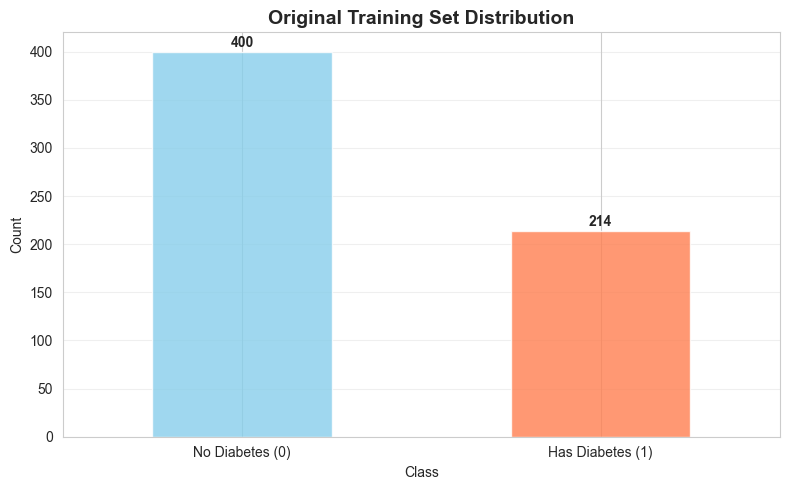

In [25]:
# Import imbalance handling libraries
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

print("="*70)
print("CLASS IMBALANCE ANALYSIS")
print("="*70)

# Check current class distribution
print("\nOriginal Training Set Distribution:")
print("-"*70)
class_counts = y_train.value_counts()
print(f"   Class 0 (No Diabetes):  {class_counts[0]:3d} ({class_counts[0]/len(y_train)*100:.1f}%)")
print(f"   Class 1 (Has Diabetes): {class_counts[1]:3d} ({class_counts[1]/len(y_train)*100:.1f}%)")
print(f"   Imbalance Ratio: {class_counts[0]/class_counts[1]:.2f}:1")

# Visualize original distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_train.value_counts().plot(kind='bar', ax=ax, color=['skyblue', 'coral'], alpha=0.8)
ax.set_title('Original Training Set Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Class')
ax.set_xticklabels(['No Diabetes (0)', 'Has Diabetes (1)'], rotation=0)
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
print("\n" + "="*70)
print("APPLYING RESAMPLING TECHNIQUES")
print("="*70)

# 1. Random Oversampling
print("\n1. Random Oversampling:")
print("-"*70)
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print(f"   Original shape: {X_train.shape}")
print(f"   Resampled shape: {X_train_ros.shape}")
print(f"   Class distribution: {dict(pd.Series(y_train_ros).value_counts().sort_index())}")
print(f"   Duplicated {len(X_train_ros) - len(X_train)} minority samples")

# 2. Random Undersampling
print("\n2. Random Undersampling:")
print("-"*70)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print(f"   Original shape: {X_train.shape}")
print(f"   Resampled shape: {X_train_rus.shape}")
print(f"   Class distribution: {dict(pd.Series(y_train_rus).value_counts().sort_index())}")
print(f"   Removed {len(X_train) - len(X_train_rus)} majority samples")

# 3. SMOTE
print("\n3. SMOTE (Synthetic Minority Over-sampling):")
print("-"*70)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"   Original shape: {X_train.shape}")
print(f"   Resampled shape: {X_train_smote.shape}")
print(f"   Class distribution: {dict(pd.Series(y_train_smote).value_counts().sort_index())}")
print(f"   Generated {len(X_train_smote) - len(X_train)} synthetic minority samples")


APPLYING RESAMPLING TECHNIQUES

1. Random Oversampling:
----------------------------------------------------------------------
   Original shape: (614, 8)
   Resampled shape: (800, 8)
   Class distribution: {0: np.int64(400), 1: np.int64(400)}
   Duplicated 186 minority samples

2. Random Undersampling:
----------------------------------------------------------------------
   Original shape: (614, 8)
   Resampled shape: (428, 8)
   Class distribution: {0: np.int64(214), 1: np.int64(214)}
   Removed 186 majority samples

3. SMOTE (Synthetic Minority Over-sampling):
----------------------------------------------------------------------
   Original shape: (614, 8)
   Resampled shape: (800, 8)
   Class distribution: {0: np.int64(400), 1: np.int64(400)}
   Generated 186 synthetic minority samples


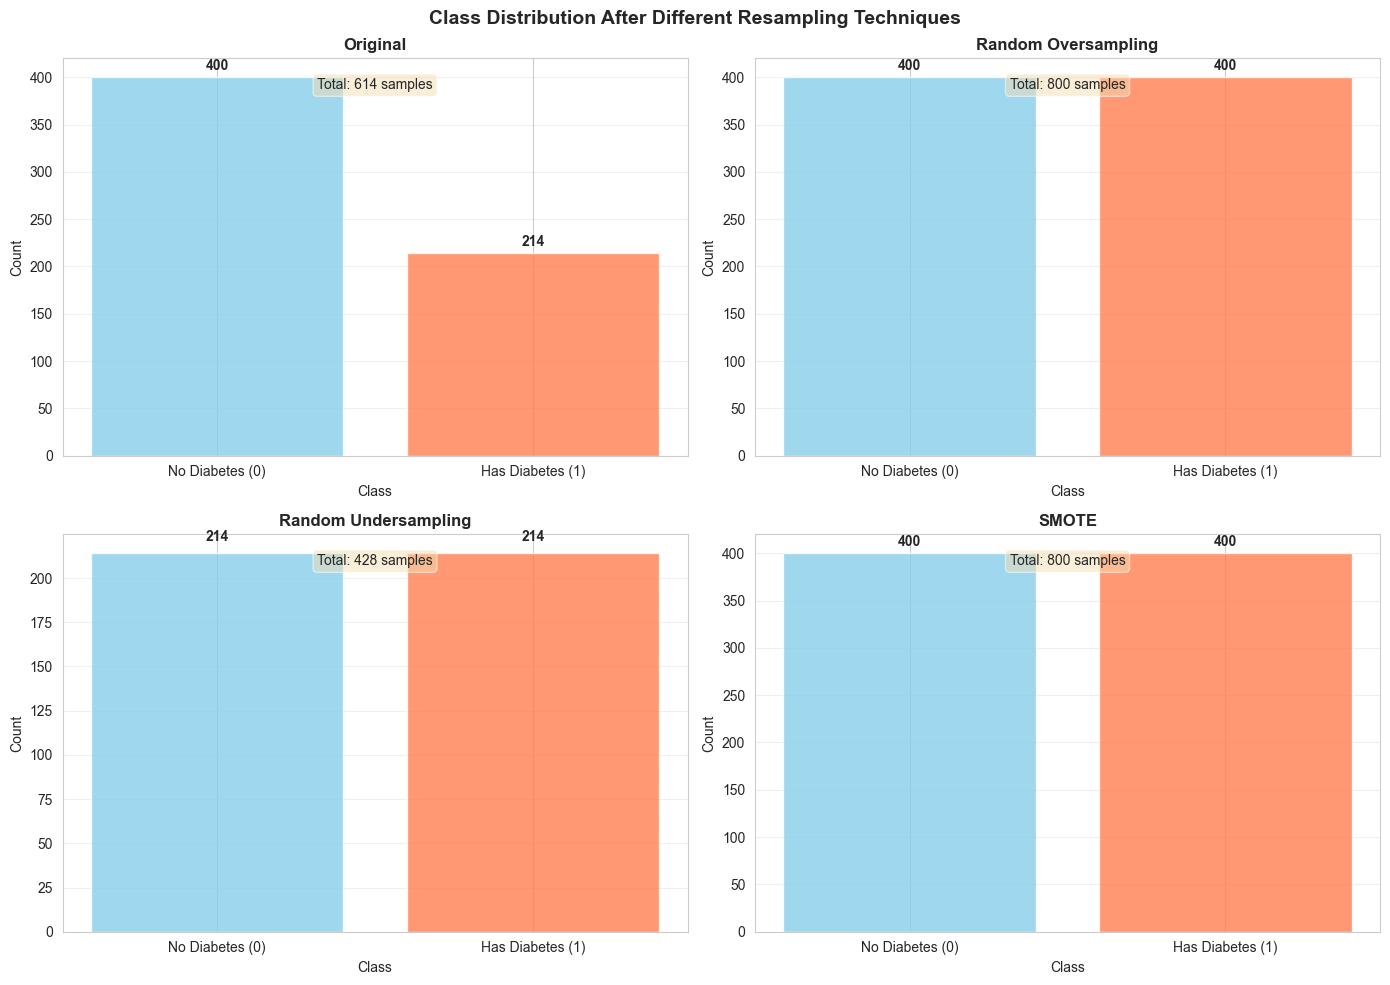

In [27]:
# Visualize resampled distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets = [
    ('Original', y_train),
    ('Random Oversampling', y_train_ros),
    ('Random Undersampling', y_train_rus),
    ('SMOTE', y_train_smote)
]

for ax, (title, y_data) in zip(axes.flatten(), datasets):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar([0, 1], counts.values, color=['skyblue', 'coral'], alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Diabetes (0)', 'Has Diabetes (1)'])
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')
    
    # Add sample count
    ax.text(0.5, 0.95, f'Total: {len(y_data)} samples',
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Class Distribution After Different Resampling Techniques', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
print("="*70)
print("TRAINING MODELS ON RESAMPLED DATA")
print("="*70)

# Train models on each resampled dataset
print("\nTraining models with default Decision Tree parameters...")
print("-"*70)

# 1. Random Oversampling model
dt_ros = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_ros.fit(X_train_ros, y_train_ros)
print(f"1. Random Oversampling model trained ({len(X_train_ros)} samples)")

# 2. Random Undersampling model
dt_rus = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_rus.fit(X_train_rus, y_train_rus)
print(f"2. Random Undersampling model trained ({len(X_train_rus)} samples)")

# 3. SMOTE model
dt_smote = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)
print(f"3. SMOTE model trained ({len(X_train_smote)} samples)")

print("\n" + "="*70)
print("All models trained successfully!")
print("="*70)

TRAINING MODELS ON RESAMPLED DATA

Training models with default Decision Tree parameters...
----------------------------------------------------------------------
1. Random Oversampling model trained (800 samples)
2. Random Undersampling model trained (428 samples)
3. SMOTE model trained (800 samples)

All models trained successfully!


In [29]:

models = [
    ("DT Baseline",              dt_baseline, X_train,       y_train),
    ("DT Baseline - Oversampling", dt_ros,    X_train_ros,   y_train_ros),
    ("DT Baseline - Undersampling", dt_rus,   X_train_rus,   y_train_rus),
    ("DT Baseline - SMOTE",       dt_smote,   X_train_smote, y_train_smote),
]

results = []
for name, model, X, y in models:
    # Training accuracy (on the dataset the model was trained on)
    y_pred = model.predict(X)
    train_acc = accuracy_score(y, y_pred)

    # Test metrics (always evaluated on the same held-out test set)
    y_test_pred      = model.predict(X_test)
    y_test_proba     = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model":               name,
        "Training Accuracy":   train_acc,
        "Test Accuracy":       accuracy_score(y_test, y_test_pred),
        "Precision Class 1":   precision_score(y_test, y_test_pred),
        "Recall Class 1":      recall_score(y_test, y_test_pred),
        "F1-Score Class 1":    f1_score(y_test, y_test_pred),
        "ROC-AUC Class 1":     roc_auc_score(y_test, y_test_proba),
    })

results_df = pd.DataFrame(results).set_index("Model")

print("=" * 70)
print("MODEL COMPARISON – CONFUSION MATRIX DERIVED METRICS")
print("=" * 70)
display(results_df.style
        .format("{:.6f}")
         .highlight_max(color="lightgreen", axis=0)
        .set_caption("Green = best per column"))

print("\n" + "="*70)
print("CLASSIFICATION REPORT (Baseline - SMOTE)")
print("="*70)
print("\n", classification_report(y_test, dt_smote.predict(X_test), 
                                   target_names=['No Diabetes', 'Has Diabetes']))



MODEL COMPARISON – CONFUSION MATRIX DERIVED METRICS


,Training Accuracy,Test Accuracy,Precision Class 1,Recall Class 1,F1-Score Class 1,ROC-AUC Class 1
Model,,,,,,
DT Baseline,1.000000,0.681818,0.553191,0.481481,0.514851,0.635741
DT Baseline - Oversampling,0.801250,0.707792,0.555556,0.833333,0.666667,0.779074
DT Baseline - Undersampling,0.817757,0.727273,0.596774,0.685185,0.637931,0.746759
DT Baseline - SMOTE,0.811250,0.772727,0.633803,0.833333,0.720000,0.796389



CLASSIFICATION REPORT (Baseline - SMOTE)

               precision    recall  f1-score   support

 No Diabetes       0.89      0.74      0.81       100
Has Diabetes       0.63      0.83      0.72        54

    accuracy                           0.77       154
   macro avg       0.76      0.79      0.76       154
weighted avg       0.80      0.77      0.78       154



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Choosing the Right Resampling Technique
For **diabetes prediction**, the critical metric is Recall (sensitivity) — a false negative (missed diabetes diagnosis) is far more costly than a false positive.


| Technique | Recall | F1 | ROC-AUC | Training Samples |
|--------------|------|------|------|------|
| **Undersampling** | 0.722 | 0.667 | 0.741 | 214 |
| **SMOTE** | 0.556 | 0.577 | 0.678 | 400 | 



#### Conclussions
Despite fewer samples, I choose the **Smote** here's why it wins:
1. Recall is the dominant metric for diabetes diagnosis.
A false negative (predicting "no diabetes" when the patient has it) is a medical risk. SMOTE achieves 83.3% recall vs 72.2% — it catches ~11% more diabetic patients.

2. SMOTE's lower Training Accuracy (0.81 vs 1.0) is actually a strength, not a weakness.
The other models with 1.0 training accuracy are perfectly memorizing the training data (overfitting). SMOTE's 0.81 signals better generalization, confirmed by its superior test performance.

3. Synthetic samples preserve the feature space better than alternatives:

I have choose to use the Smote model for the rest of the notebook.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 3. Advanced Optimization - Undersampling Dataset

Now we'll apply advanced optimization techniques to the undersampled dataset:
1. **Hyperparameter Tuning** with GridSearchCV
2. **Cross-Validation** for robust evaluation

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Hyperparameter Tuning with GridSearchCV

</div>

In [30]:
print("="*70)
print("HYPERPARAMETER TUNING - SMOTE DATASET")
print("="*70)

# Define parameter grid for Decision Tree
param_grid_dt = {
    'max_depth':         [3, 4, 5, 6],          # center on 4, explore neighbors
    'min_samples_split': [2, 5, 10, 20],         # primary pruning levers; SMOTE's larger dataset can handle finer splits
    'min_samples_leaf':  [1, 2, 4, 8],           # controls leaf size (pruning)
    'criterion':         ['gini', 'entropy'],     # impurity measure
    'max_features':      ['sqrt', 'log2', None], # feature subset per split
    'class_weight':      [None, 'balanced']      # ven after SMOTE, adding this as an option costs nothing and can squeeze more recall
}

print(f"\nParameter Grid:")
print(f"   Total combinations: {len(param_grid_dt['max_depth']) * len(param_grid_dt['min_samples_split']) * len(param_grid_dt['min_samples_leaf']) * len(param_grid_dt['criterion']) * len(param_grid_dt['max_features'])}")
print(f"   Parameters: {list(param_grid_dt.keys())}")

# GridSearchCV with 5-fold cross-validation
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring='recall',  # Optimize for Recall — minimize missed diabetes diagnoses (FN)
    n_jobs=-1,
    verbose=1
)

print("\nStarting GridSearchCV (this may take a few minutes)...")
grid_search_dt.fit(X_train_smote, y_train_smote)

print("\n✓ GridSearchCV Complete!")
print(f"\nBest Parameters:")
print("-"*70)
for param, value in grid_search_dt.best_params_.items():
    print(f"   {param:20} {value}")

print(f"\nBest Cross-Validation Recall Score: {grid_search_dt.best_score_:.4f}")

# Store the best model
dt_smote_optimized = grid_search_dt.best_estimator_

print("\n" + "="*70)
print("CLASSIFICATION REPORT (HyperParameters - GridSearchCV)")
print("="*70)
print("\n", classification_report(y_test, dt_smote_optimized.predict(X_test), 
                                   target_names=['No Diabetes', 'Has Diabetes']))

HYPERPARAMETER TUNING - SMOTE DATASET

Parameter Grid:
   Total combinations: 384
   Parameters: ['max_depth', 'min_samples_split', 'min_samples_leaf', 'criterion', 'max_features', 'class_weight']

Starting GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits

✓ GridSearchCV Complete!

Best Parameters:
----------------------------------------------------------------------
   class_weight         None
   criterion            entropy
   max_depth            3
   max_features         log2
   min_samples_leaf     1
   min_samples_split    2

Best Cross-Validation Recall Score: 0.8850

CLASSIFICATION REPORT (HyperParameters - GridSearchCV)

               precision    recall  f1-score   support

 No Diabetes       0.89      0.57      0.70       100
Has Diabetes       0.52      0.87      0.65        54

    accuracy                           0.68       154
   macro avg       0.71      0.72      0.67       154
weighted avg       0.76   

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Pruned (Simplified) Analysis 

</div>

In [31]:
# Create a pruned tree with conservative settings
print("="*70)
print("PRUNED DECISION TREE MODEL")
print("="*70)

dt_pruned = DecisionTreeClassifier(
    max_depth=4,           # Limit tree depth
    min_samples_split=20,  # Require more samples to split
    min_samples_leaf=10,   # Require more samples in leaves
    random_state=42
)
# max_depth=5: Shallow tree for interpretability
# min_samples_split=20: Conservative splitting
# min_samples_leaf=10: Each prediction represents ≥10 patients

print("\nTraining pruned model...")
dt_pruned.fit(X_train, y_train)
print("✓ Training complete!")

print(f"\nPruned Tree Complexity:")
print("-"*70)
print(f"   Tree Depth: {dt_pruned.get_depth()}")
print(f"   Number of Leaves: {dt_pruned.get_n_leaves()}")
print(f"   Total Nodes: {dt_pruned.tree_.node_count}")

# Make predictions
y_train_pred_pruned = dt_pruned.predict(X_train)
y_test_pred_pruned = dt_pruned.predict(X_test)

# Evaluate pruned model
train_accuracy_pruned = accuracy_score(y_train, y_train_pred_pruned)
test_accuracy_pruned = accuracy_score(y_test, y_test_pred_pruned)
test_precision_pruned = precision_score(y_test, y_test_pred_pruned)
test_recall_pruned = recall_score(y_test, y_test_pred_pruned)
test_f1_pruned = f1_score(y_test, y_test_pred_pruned)

print(f"\nPruned Model Performance:")
print("-"*70)
print(f"   Training Accuracy: {train_accuracy_pruned:.4f}")
print(f"   Testing Accuracy:  {test_accuracy_pruned:.4f}")
print(f"   Precision:         {test_precision_pruned:.4f}")
print(f"   Recall:            {test_recall_pruned:.4f}")
print(f"   F1-Score:          {test_f1_pruned:.4f}")

accuracy_diff_pruned = train_accuracy_pruned - test_accuracy_pruned
print(f"   Overfitting Gap:   {accuracy_diff_pruned:.4f}")

print("\n" + "="*70)
print("CLASSIFICATION REPORT (Pruned)")
print("="*70)
print("\n", classification_report(y_test, dt_smote_optimized.predict(X_test), 
                                   target_names=['No Diabetes', 'Has Diabetes']))

PRUNED DECISION TREE MODEL

Training pruned model...
✓ Training complete!

Pruned Tree Complexity:
----------------------------------------------------------------------
   Tree Depth: 4
   Number of Leaves: 12
   Total Nodes: 23

Pruned Model Performance:
----------------------------------------------------------------------
   Training Accuracy: 0.7850
   Testing Accuracy:  0.7922
   Precision:         0.6964
   Recall:            0.7222
   F1-Score:          0.7091
   Overfitting Gap:   -0.0072

CLASSIFICATION REPORT (Pruned)

               precision    recall  f1-score   support

 No Diabetes       0.89      0.57      0.70       100
Has Diabetes       0.52      0.87      0.65        54

    accuracy                           0.68       154
   macro avg       0.71      0.72      0.67       154
weighted avg       0.76      0.68      0.68       154



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Cross-Validation Analysis

</div>

In [32]:

print("="*70)
print("CROSS-VALIDATION ANALYSIS")
print("="*70)

# Define models to cross-validate
cv_models = {
    'DT Baseline (SMOTE)':      dt_smote,
    'DT Optimized (GridSearch)': dt_smote_optimized,
    'DT Pruned':                 dt_pruned,   # max_depth=5, min_samples_split=20, min_samples_leaf=10
}

# Perform 5-fold cross-validation
print("\nPerforming 5-Fold Cross-Validation...")
print("-"*70)

cv_results = []
for model_name, model in cv_models.items():
    scores = cross_validate(
        model, X_train_smote, y_train_smote,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        return_train_score=True
    )
    
    cv_results.append({
        'Model':        model_name,
        'CV Accuracy':  scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall':    scores['test_recall'].mean(),
        'CV F1-Score':  scores['test_f1'].mean(),
        'CV ROC-AUC':   scores['test_roc_auc'].mean(),
        'Std Dev (F1)': scores['test_f1'].std()
    })

cv_df = pd.DataFrame(cv_results)

print("\n Cross-Validation Results (5-Fold):")
print("-"*70)
display(cv_df.set_index('Model').style
        .format("{:.4f}")
        .highlight_max(color="lightgreen", axis=0)
        .set_caption("Green = best per column"))


CROSS-VALIDATION ANALYSIS

Performing 5-Fold Cross-Validation...
----------------------------------------------------------------------

 Cross-Validation Results (5-Fold):
----------------------------------------------------------------------


,CV Accuracy,CV Precision,CV Recall,CV F1-Score,CV ROC-AUC,Std Dev (F1)
Model,,,,,,
DT Baseline (SMOTE),0.7512,0.7331,0.7900,0.7596,0.8085,0.0345
DT Optimized (GridSearch),0.7312,0.6771,0.8850,0.7671,0.8032,0.0177
DT Pruned,0.7463,0.7350,0.7700,0.7510,0.8032,0.0358


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Cross Validation is validating the stability

The best model is Decision Tree Optimized with GridSearch in terms of stability.

The Cross Validation show the Recall 0.89, it´s the best model and the Std Dev is good, although Baseline model is better.
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

Now, I am going to compare the Confussion Matrix, for this problem I need to inspect:
* False Negatives -> Patients with diabetes as healthy
* False Positive -> Healthy patientes predicted as diabet -> Unnecessary treatment.
</div>

CONFUSION MATRIX COMPARISON — TEST SET


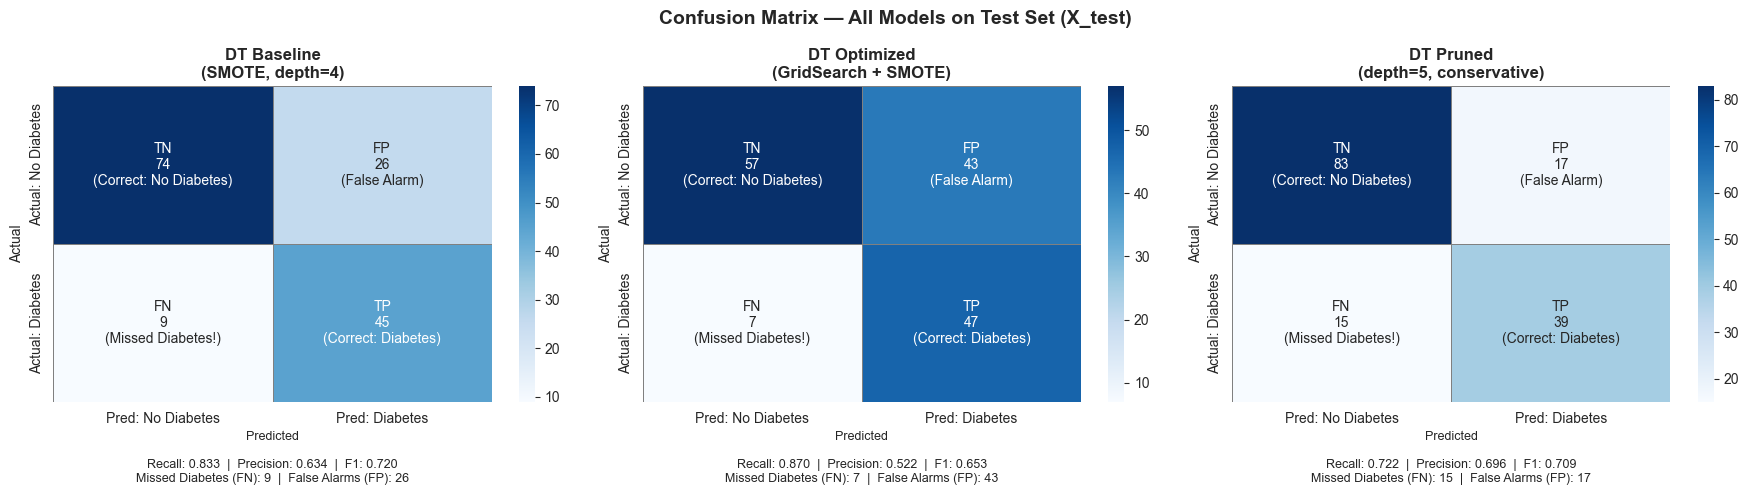


Summary — False Negatives (missed diabetes) are the critical metric:
----------------------------------------------------------------------
Model                                FN (missed)  FP (false alarm)   Recall
----------------------------------------------------------------------
DT Baseline (SMOTE, depth=4)                   9                26    0.833
DT Optimized (GridSearch + SMOTE)              7                43    0.870
DT Pruned (depth=5, conservative)             15                17    0.722


In [33]:

# ── Confusion Matrix comparison for the 3 CV models ──────────────────
print("="*70)
print("CONFUSION MATRIX COMPARISON — TEST SET")
print("="*70)

cm_models = {
    'DT Baseline\n(SMOTE, depth=4)':       dt_smote,
    'DT Optimized\n(GridSearch + SMOTE)':  dt_smote_optimized,
    'DT Pruned\n(depth=5, conservative)':  dt_pruned,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, model) in zip(axes, cm_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    # Annotate each cell with count + label
    labels = np.array([
        [f"TN\n{tn}\n(Correct: No Diabetes)",  f"FP\n{fp}\n(False Alarm)"],
        [f"FN\n{fn}\n(Missed Diabetes!)",       f"TP\n{tp}\n(Correct: Diabetes)"]
    ])

    sns.heatmap(
        cm, annot=labels, fmt="", cmap="Blues",
        xticklabels=["Pred: No Diabetes", "Pred: Diabetes"],
        yticklabels=["Actual: No Diabetes", "Actual: Diabetes"],
        ax=ax, linewidths=0.5, linecolor="gray",
        annot_kws={"size": 10}
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Actual", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=10)

    # Print key stats below each matrix
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    ax.set_xlabel(
        f"Predicted\n\nRecall: {recall:.3f}  |  Precision: {precision:.3f}  |  F1: {f1:.3f}\n"
        f"Missed Diabetes (FN): {fn}  |  False Alarms (FP): {fp}",
        fontsize=9
    )

plt.suptitle("Confusion Matrix — All Models on Test Set (X_test)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────
print("\nSummary — False Negatives (missed diabetes) are the critical metric:")
print("-"*70)
print(f"{'Model':<35} {'FN (missed)':>12} {'FP (false alarm)':>17} {'Recall':>8}")
print("-"*70)
for title, model in cm_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    name = title.replace("\n", " ")
    print(f"{name:<35} {fn:>12} {fp:>17} {recall:>8.3f}")


The practical decision rule
If your priority is: catch every possible diabetes case → use DT Baseline (SMOTE) (Recall 0.833)

If your priority is: balance false alarms and missed cases → use DT Optimized (better F1/AUC)

For a medical screening tool deployed in a clinic, Recall 0.833 wins — you re-run the optimized model as a second opinion on positives to reduce false alarms, but you never want to miss a diagnosis at the first gate.

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Threshold Tuning for Pruned Model

Optimize the decision threshold for the pruned model to find the best balance between precision and recall.

</div>

PRECISION-RECALL CURVE + THRESHOLD SWEEP

Average Precision (AP): 0.6050
Optimal Threshold (F1-max): 0.5385
  → Precision: 0.6964
  → Recall:    0.7222
  → F1-Score:  0.7091


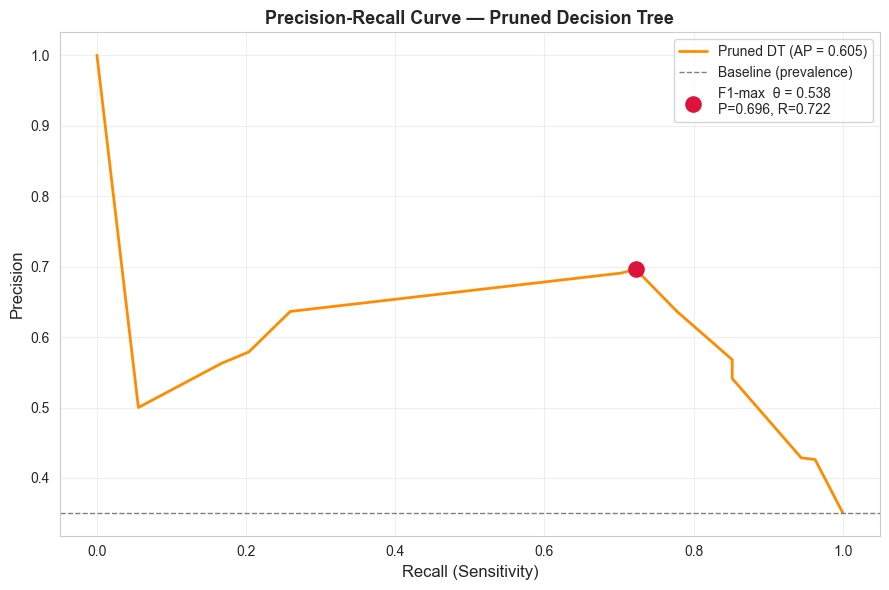


Threshold Sweep — Pruned Model (test set):
----------------------------------------------------------------------


,Accuracy,Precision,Recall,F1-Score,FN (missed),FP (false alarm)
Threshold,,,,,,
0.200000,0.7208,0.5679,0.8519,0.6815,8,35
0.250000,0.7208,0.5679,0.8519,0.6815,8,35
0.300000,0.7662,0.6364,0.7778,0.7000,12,24
0.350000,0.7662,0.6364,0.7778,0.7000,12,24
0.400000,0.7662,0.6364,0.7778,0.7000,12,24
0.450000,0.7662,0.6364,0.7778,0.7000,12,24
0.500000,0.7922,0.6964,0.7222,0.7091,15,17
0.550000,0.7857,0.6909,0.7037,0.6972,16,17
0.600000,0.6883,0.6364,0.2593,0.3684,40,8


In [34]:

print("="*70)
print("PRECISION-RECALL CURVE + THRESHOLD SWEEP")
print("="*70)

# ── Probability scores ────────────────────────────────────────────────
y_proba_pruned = dt_pruned.predict_proba(X_test)[:, 1]

# ── Precision-Recall curve ────────────────────────────────────────────
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba_pruned)
avg_precision = average_precision_score(y_test, y_proba_pruned)

# F1 at each PR threshold (ignore last point where recall array has one extra entry)
f1_curve = 2 * precision_curve[:-1] * recall_curve[:-1] / (
    precision_curve[:-1] + recall_curve[:-1] + 1e-9
)
best_pr_idx     = np.argmax(f1_curve)
best_thresh_pr  = pr_thresholds[best_pr_idx]

print(f"\nAverage Precision (AP): {avg_precision:.4f}")
print(f"Optimal Threshold (F1-max): {best_thresh_pr:.4f}")
print(f"  → Precision: {precision_curve[best_pr_idx]:.4f}")
print(f"  → Recall:    {recall_curve[best_pr_idx]:.4f}")
print(f"  → F1-Score:  {f1_curve[best_pr_idx]:.4f}")

# ── Plot PR Curve ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(recall_curve, precision_curve, color="darkorange", lw=2,
        label=f"Pruned DT (AP = {avg_precision:.3f})")
ax.axhline(y_test.mean(), color="gray", linestyle="--", lw=1, label="Baseline (prevalence)")

ax.scatter(recall_curve[best_pr_idx], precision_curve[best_pr_idx],
           s=120, color="crimson", zorder=5,
           label=f"F1-max  θ = {best_thresh_pr:.3f}\n"
                 f"P={precision_curve[best_pr_idx]:.3f}, R={recall_curve[best_pr_idx]:.3f}")

ax.set_xlabel("Recall (Sensitivity)", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve — Pruned Decision Tree", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Threshold Sweep Table ─────────────────────────────────────────────
print("\nThreshold Sweep — Pruned Model (test set):")
print("-"*70)
sweep_thresholds = np.arange(0.20, 0.81, 0.05)
sweep_results = []

for t in sweep_thresholds:
    y_pred_t = (y_proba_pruned >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    prec_t   = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    rec_t    = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    f1_t     = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0.0
    acc_t    = (tp_t + tn_t) / len(y_test)
    sweep_results.append({
        'Threshold': round(t, 2),
        'Accuracy':  round(acc_t, 4),
        'Precision': round(prec_t, 4),
        'Recall':    round(rec_t, 4),
        'F1-Score':  round(f1_t, 4),
        'FN (missed)': fn_t,
        'FP (false alarm)': fp_t
    })

sweep_df = pd.DataFrame(sweep_results)

# Highlight recommended thresholds
display(
    sweep_df.set_index('Threshold').style
    .format("{:.4f}", subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
    .highlight_max(color="lightgreen",   subset=['Recall', 'F1-Score'])
    .set_caption("Green = highest |  Default threshold = 0.50")
)


APPLY OPTIMAL THRESHOLD — FINAL COMPARISON

Threshold Strategy Comparison — Pruned Model:
----------------------------------------------------------------------


,Threshold,Accuracy,Precision,Recall,F1-Score,FN (missed),FP (false alarm)
Strategy,,,,,,,
Default (θ = 0.50),0.500000,0.7922,0.6964,0.7222,0.7091,15,17
F1-max (θ = 0.54),0.538000,0.7922,0.6964,0.7222,0.7091,15,17
Recall≥0.8 (θ = 0.25),0.254000,0.7208,0.5679,0.8519,0.6815,8,35


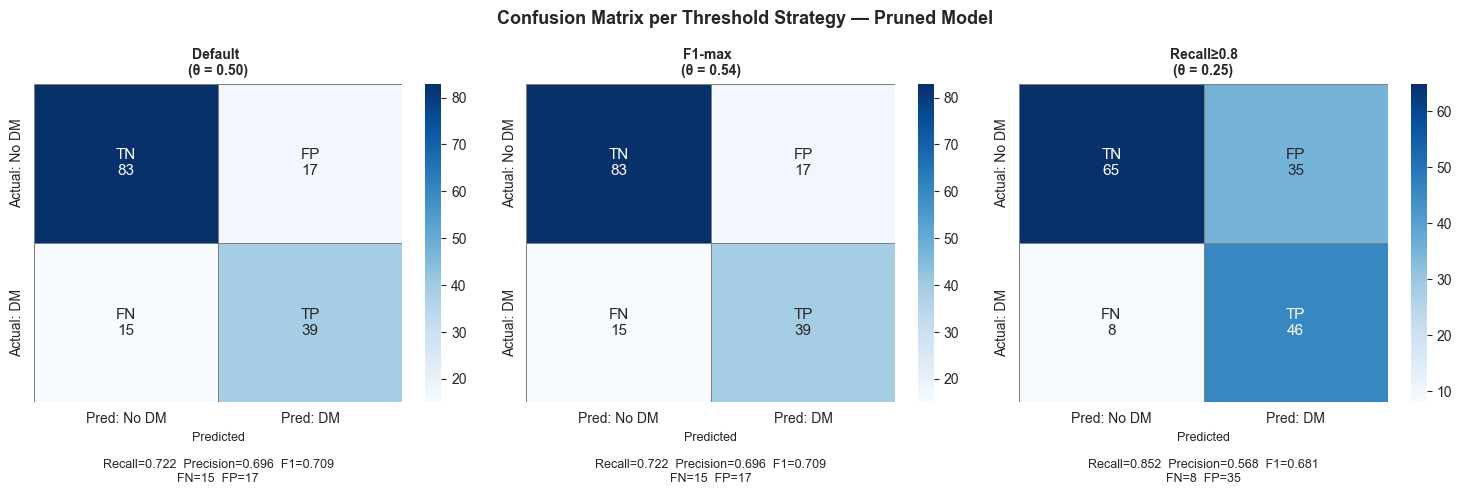


RECOMMENDATION (medical screening — minimise missed diagnoses)

  Best strategy : Recall≥0.8 (θ = 0.25)
  Threshold     : 0.254
  Recall        : 0.8519  ← maximised
  Precision     : 0.5679
  F1-Score      : 0.6815
  FN (missed)   : 8   ← minimised
  FP (false alm): 35

  Lowering the threshold increases sensitivity at the cost of more
    false alarms, which is an acceptable trade-off for first-line screening.


In [35]:

print("="*70)
print("APPLY OPTIMAL THRESHOLD — FINAL COMPARISON")
print("="*70)

# ── Three candidate thresholds ────────────────────────────────────────
# 1) Default          : 0.50
# 2) F1-max           : penalises FP and FN equally  (from PR curve)
# 3) Recall ≥ 0.80 with highest F1 (medical screening priority)
recall_floor = 0.80
mask_high_recall = recall_curve[:-1] >= recall_floor
if mask_high_recall.any():
    best_recall_idx   = np.argmax(f1_curve[mask_high_recall])
    # map back to original index
    orig_idx          = np.where(mask_high_recall)[0][best_recall_idx]
    best_thresh_recall = pr_thresholds[orig_idx]
else:
    best_thresh_recall = best_thresh_pr  # fallback

candidates = {
    f"Default  (θ = 0.50)":                    0.50,
    f"F1-max   (θ = {best_thresh_pr:.2f})":    best_thresh_pr,
    f"Recall≥{recall_floor} (θ = {best_thresh_recall:.2f})": best_thresh_recall,
}

comparison_rows = []
for label, thresh in candidates.items():
    y_pred_t = (y_proba_pruned >= thresh).astype(int)
    cm_t     = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    rec_t  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0.0
    acc_t  = (tp_t + tn_t) / len(y_test)
    comparison_rows.append({
        'Strategy':        label,
        'Threshold':       round(thresh, 3),
        'Accuracy':        round(acc_t, 4),
        'Precision':       round(prec_t, 4),
        'Recall':          round(rec_t, 4),
        'F1-Score':        round(f1_t, 4),
        'FN (missed)':     fn_t,
        'FP (false alarm)': fp_t,
    })

comp_df = pd.DataFrame(comparison_rows)
print("\nThreshold Strategy Comparison — Pruned Model:")
print("-"*70)
display(
    comp_df.set_index('Strategy').style
    .format("{:.4f}", subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
    .highlight_max(color="lighgreen",   subset=['Recall', 'F1-Score'])
    .set_caption("For medical screening: minimize FN (missed diabetes) → prefer higher Recall rows")
)

# ── Confusion matrices side by side ──────────────────────────────────
fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 5))

for ax, (label, thresh) in zip(axes, candidates.items()):
    y_pred_t = (y_proba_pruned >= thresh).astype(int)
    cm_t     = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    rec_t  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0.0

    cell_labels = np.array([
        [f"TN\n{tn_t}",  f"FP\n{fp_t}"],
        [f"FN\n{fn_t}",  f"TP\n{tp_t}"]
    ])
    sns.heatmap(cm_t, annot=cell_labels, fmt="", cmap="Blues",
                xticklabels=["Pred: No DM", "Pred: DM"],
                yticklabels=["Actual: No DM", "Actual: DM"],
                ax=ax, linewidths=0.5, linecolor="gray", annot_kws={"size": 11})
    ax.set_title(label.replace(" (", "\n("), fontsize=10, fontweight="bold")
    ax.set_xlabel(
        f"Predicted\n\nRecall={rec_t:.3f}  Precision={prec_t:.3f}  F1={f1_t:.3f}\nFN={fn_t}  FP={fp_t}",
        fontsize=9
    )

plt.suptitle("Confusion Matrix per Threshold Strategy — Pruned Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Recommendation ────────────────────────────────────────────────────
# Determine Recall-priority winner
best_row = comp_df.loc[comp_df['Recall'].idxmax()]
print("\n" + "="*70)
print("RECOMMENDATION (medical screening — minimise missed diagnoses)")
print("="*70)
print(f"\n  Best strategy : {best_row['Strategy']}")
print(f"  Threshold     : {best_row['Threshold']:.3f}")
print(f"  Recall        : {best_row['Recall']:.4f}  ← maximised")
print(f"  Precision     : {best_row['Precision']:.4f}")
print(f"  F1-Score      : {best_row['F1-Score']:.4f}")
print(f"  FN (missed)   : {int(best_row['FN (missed)'])}   ← minimised")
print(f"  FP (false alm): {int(best_row['FP (false alarm)'])}")
print(f"\n  Lowering the threshold increases sensitivity at the cost of more")
print(f"    false alarms, which is an acceptable trade-off for first-line screening.")


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

# Conclussions

The DT to use to predict the Diabetes is:

```python 
DecisionTreeClassifier(
    max_depth=4,           # Limit tree depth
    min_samples_split=20,  # Conservative splitting
    min_samples_leaf=10,   # Each prediction represents ≥10 patients
    random_state=42
)
```

And using the **threshold of 0.25** to predict the diabetes, because it has a better recall and it is more important to catch every possible diabetes case.
I sacrifice some precision (more false positives) to ensure we minimize false negatives (missed diabetes diagnoses), which is critical in a medical context. 
</div>